# KNN Algoritması & Parametre Seçimleri

Bu dersin sonunda şunları yapabiliyor olmayı hedefliyoruz:

1. KNN algoritmasını anlamak
2. Modellerimiz bizden bekledikleri parametrelere karar vermek
3. GridSearchCV ve RandomizedSearchCV yöntemlerini kavramak

## Popüler Bir Veri Seti: İris Veri Seti

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()

iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [2]:
X = iris.data
y = iris.target

In [3]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [4]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

# 1. Model Değerlendirme Prosedürleri

## 1.1. Tüm Veri Setiyle Çalışma (Pek Tercih Edilmez)

1. Tüm veri setiyle modeli eğit
2. Aynı veri setiyle modeli test et

### KNN Algoritması (K=5)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

knn = KNeighborsClassifier(n_neighbors=5) # En yakın 5 komşuya bak
knn.fit(X, y) # Veri setinin tümüyle eğit
y_pred = knn.predict(X) # Eğitiğin veri setiyle test et

print(metrics.accuracy_score(y, y_pred))

0.9666666666666667


### KNN (K=1)

In [6]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)
y_pred = knn.predict(X)

print(metrics.accuracy_score(y, y_pred))

1.0


## 1.2. Train/Test Ayrımı Yapılması (Daha Doğru Sonuçlar)

1. Veri setini 2 veya 3 parçaya ayır
2. Eğitim için ayırdığın parçayla modeli eğit
3. Test için ayırdığın parçayla modeli test et

In [7]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
print(X_train.shape) # Eğitim için %70 
print(X_test.shape) # Test için %30

(105, 4)
(45, 4)


In [10]:
print(y_train.shape)
print(y_test.shape)

(105,)
(45,)


Veri setimizi uygun bir şekilde böldükten sonra tekrar modelimizi oluşturalım.

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(metrics.accuracy_score(y_test, y_pred))

1.0


In [12]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(metrics.accuracy_score(y_test, y_pred))

1.0


- Veri setimizi böldükten sonra 5 komşu kullanarak geliştirdiğimiz modelin accuracy değerinde bir artış, 1 komşu kullanarak geliştirdiğimiz modlein accuracy değerinde ise bir azalış gerçekleşti. Böylesi daha doğru!

## 1.3. Cross Validation (Sonuçlardan Emin Olmak)

1. Veri setini farklı formatlarda ayır
2. Her bir formattan elde edilen doğruluk değerlerini değerlendir
3. Ortalamalarını alarak en iyi olana karar ver
4. Özellikle büyük veri setlerinde işlem süresi uzayabilir (dezavantaj)

In [13]:
from sklearn.model_selection import cross_val_score

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn, X, y, cv=10, scoring='accuracy') # Veri setini 10 farklı formatta hazırla
print(scores)

[1.         0.93333333 1.         1.         0.86666667 0.93333333
 0.93333333 1.         1.         1.        ]


In [15]:
# Elde ettiğimiz bu accuracy değerlerinden bir çıkarım yapabilmek için aritmetik ortalama almak oldukça mantıklı bir yöntem
print(scores.mean())

0.9666666666666668


Hatırlarsanız KNN algoritmasını işlerken **komşu sayısını(k parametresi)** doğru bir şekilde belirlemenin ne kadar önemli olduğunu konuşmuştuk. Ama bu değeri belirlerken tabiki olabilecek en doğru model sonucuna erişmek istiyoruz.

- O zaman hadi bunu nasıl yapabileceğimize bakalım.

In [16]:
k_range = list(range(1, 31)) # İlk olarak 1'den 30'a kadar olan k parametrelerini test edelim
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10, scoring='accuracy')
    k_scores.append(scores.mean())
print(k_scores)

[0.96, 0.9533333333333334, 0.9666666666666666, 0.9666666666666666, 0.9666666666666668, 0.9666666666666668, 0.9666666666666668, 0.9666666666666668, 0.9733333333333334, 0.9666666666666668, 0.9666666666666668, 0.9733333333333334, 0.9800000000000001, 0.9733333333333334, 0.9733333333333334, 0.9733333333333334, 0.9733333333333334, 0.9800000000000001, 0.9733333333333334, 0.9800000000000001, 0.9666666666666666, 0.9666666666666666, 0.9733333333333334, 0.96, 0.9666666666666666, 0.96, 0.9666666666666666, 0.9533333333333334, 0.9533333333333334, 0.9533333333333334]


- Burada her bir k parametresine karşılık hesaplanan accuracy sonuçlarını elde etmiş olduk. Şimdi elde ettiğimiz bu çıktıyı bir görsele aktararak sonuçların anlaşılmasını kolaylaştıralım.

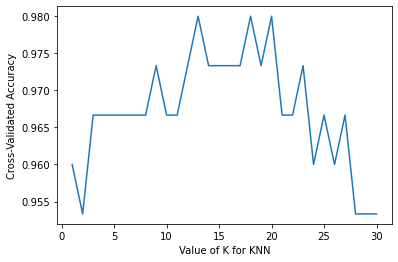

In [17]:
import matplotlib.pyplot as plt

plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy');

> **SORU:** Hangi komşu sayıları bizim modelimizdeki doğruluğu en üst seviyeye taşımış gibi duruyor?

- Şimdi de, en optimum komşu sayısını bulduğumuzdan emin olmak için bu değerlendirmemizi biraz daha geniş bir ölçekte gerçekleştirelim.

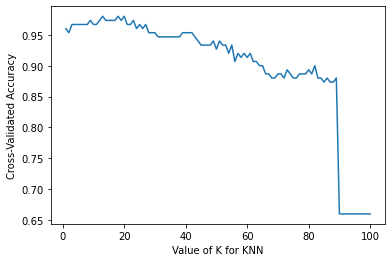

In [18]:
k_range = list(range(1, 101)) # Bu sefer 1'den 100'e kadar olan k parametrelerini test edelim
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10, scoring='accuracy')
    k_scores.append(scores.mean())

plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy');

> **SORU:** Hangi komşu sayısı bizim için en optimum seçenek olarak duruyor?

Ama görselden ancak varsayımsal bir çıkarım yapabiliyoruz. Ama bizim, bize en yüksek doğruluğu veren k parametresine ihtiyacımız var. Hadi onu bulalım.

In [19]:
for index, value in enumerate(k_scores):
    k_param = index+1
    print(k_param, value)

1 0.96
2 0.9533333333333334
3 0.9666666666666666
4 0.9666666666666666
5 0.9666666666666668
6 0.9666666666666668
7 0.9666666666666668
8 0.9666666666666668
9 0.9733333333333334
10 0.9666666666666668
11 0.9666666666666668
12 0.9733333333333334
13 0.9800000000000001
14 0.9733333333333334
15 0.9733333333333334
16 0.9733333333333334
17 0.9733333333333334
18 0.9800000000000001
19 0.9733333333333334
20 0.9800000000000001
21 0.9666666666666666
22 0.9666666666666666
23 0.9733333333333334
24 0.96
25 0.9666666666666666
26 0.96
27 0.9666666666666666
28 0.9533333333333334
29 0.9533333333333334
30 0.9533333333333334
31 0.9466666666666667
32 0.9466666666666667
33 0.9466666666666667
34 0.9466666666666667
35 0.9466666666666667
36 0.9466666666666667
37 0.9466666666666667
38 0.9466666666666667
39 0.9533333333333334
40 0.9533333333333334
41 0.9533333333333334
42 0.9533333333333334
43 0.9466666666666667
44 0.9400000000000001
45 0.9333333333333333
46 0.9333333333333333
47 0.9333333333333333
48 0.933333333333

Burada tüm k parametrelerine denk gelen doğruluk değerlerini görüntüleyebiliyoruz. Burada gözle inceleyerek de en iyi k parametresini bulabiliriz ancak biz kodlama biliyoruz, o yüzden bunu otomatikleştirmemiz lazım :)

In [20]:
for index, value in enumerate(k_scores):
    k_param = index+1
    max_value = max(k_scores)
print('Best K Parameter:', 1+k_scores.index(max_value))

Best K Parameter: 13


## 1.4. En İyi Parametreleri Bulma (GridSearchCV)

In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
# GridSearchCV'nin bakacağı k parametrelerini seçiyoruz
k_range = list(range(1, 100))
print(k_range)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


In [23]:
# Birazdan elde edeceğimiz sonuçta bazı sayıların ne anlam ifade ettiğini karıştırmamak için bir dictionary yapısı kuralım
param_grid = dict(n_neighbors=k_range)
print(param_grid)

{'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]}


In [24]:
# GridSearchCV'yi tanımlama
grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')

In [25]:
# GridSearchCV'yi çalıştırma
grid.fit(X, y)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(n_neighbors=100),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30, ...]},
             scoring='accuracy')

In [26]:
# Elde ettiğimiz sonuçları görüntüleme
grid.cv_results_

{'mean_fit_time': array([5.59449196e-04, 8.75353813e-04, 1.01089478e-04, 3.99374962e-04,
        5.50866127e-04, 4.01020050e-04, 1.05149746e-03, 1.01256371e-04,
        8.51988792e-04, 0.00000000e+00, 1.63431168e-03, 0.00000000e+00,
        0.00000000e+00, 5.50985336e-05, 1.51348114e-04, 1.34205818e-04,
        1.34086609e-04, 1.65493488e-03, 2.39419937e-04, 7.51686096e-04,
        1.15323067e-03, 4.00996208e-04, 0.00000000e+00, 3.00502777e-04,
        1.32679939e-04, 2.86602974e-04, 0.00000000e+00, 1.38616562e-04,
        2.01797485e-04, 9.02152061e-04, 4.01067734e-04, 1.01184845e-04,
        4.00996208e-04, 1.01113319e-04, 0.00000000e+00, 1.00779533e-04,
        1.70819759e-03, 0.00000000e+00, 2.46667862e-04, 4.01115417e-04,
        1.41167641e-04, 4.01091576e-04, 5.10215759e-05, 7.50970840e-04,
        4.50968742e-04, 4.52160835e-04, 1.01184845e-04, 1.39045715e-04,
        3.99756432e-04, 4.99057770e-04, 3.30305099e-04, 3.99351120e-04,
        0.00000000e+00, 7.02285767e-04, 8.47506

In [27]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

def examine_results(model_grid):
    print("std_test_score", model_grid.cv_results_['std_test_score'])
    print("rank_test_score", model_grid.cv_results_['rank_test_score'])
    print("mean_test_score", model_grid.cv_results_['mean_test_score'])
    
examine_results(grid)

std_test_score [0.05333333 0.05206833 0.04472136 0.04472136 0.04472136 0.04472136
 0.04472136 0.04472136 0.03265986 0.04472136 0.04472136 0.03265986
 0.0305505  0.04422166 0.03265986 0.03265986 0.03265986 0.0305505
 0.03265986 0.0305505  0.03333333 0.03333333 0.03265986 0.04422166
 0.03333333 0.04422166 0.04472136 0.04268749 0.04268749 0.04268749
 0.04988877 0.04988877 0.04988877 0.04988877 0.04988877 0.04988877
 0.04988877 0.05811865 0.04268749 0.04268749 0.04268749 0.04268749
 0.04988877 0.05537749 0.05962848 0.0421637  0.0421637  0.0421637
 0.04666667 0.0359011  0.04666667 0.05962848 0.05962848 0.06531973
 0.05962848 0.06110101 0.04988877 0.05206833 0.04988877 0.05206833
 0.05811865 0.06110101 0.06110101 0.05374838 0.05374838 0.06
 0.06       0.05811865 0.06531973 0.06699917 0.06699917 0.05811865
 0.06798693 0.05206833 0.05811865 0.05811865 0.06699917 0.05206833
 0.05206833 0.04422166 0.05206833 0.04472136 0.0718022  0.0718022
 0.07571878 0.05811865 0.06960204 0.06960204 0.07774603 

> **PYTHON ALIŞTIRMASI:** GridSearchCV kullanarak elde ettiğimiz bu sonuçlar içerisinden en iyi model skorunu ve ona karşılık gelen k parametresini döndüren bir fonksiyon yazın.

In [28]:
# Fonksiyonunuzu buraya yazabilirsiniz...

Buraya kadar sadece k parametresinin optimum değerini bulmaya çalıştık. Ama KNN algoritmasına tanımlayabileceğimiz başka parametrelerimiz de var. Mesela **weights** parametresi! Hadi GridSearchCV kullanarak bu parametrenin de optimum değerini bulmaya çalışalım.

In [29]:
# Hangi parametrelerin değerlendirileceğini tanımlama
k_range = list(range(1, 31))
weight_options = ['uniform', 'distance']

In [30]:
# Dictionary yapısını tekrardan kuruyoruz
param_grid = dict(n_neighbors=k_range, weights=weight_options)
print(param_grid)

{'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30], 'weights': ['uniform', 'distance']}


In [31]:
# GridSearchCV'yi tanımlıyoruz
grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')
grid.fit(X, y)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(n_neighbors=100),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [32]:
# Elde ettiğimiz sonuçları görüntüleme
grid.cv_results_

{'mean_fit_time': array([0.00000000e+00, 4.01186943e-04, 5.46622276e-04, 4.02140617e-04,
        1.99365616e-04, 4.46319580e-04, 8.03899765e-04, 4.05955315e-04,
        2.99763680e-04, 0.00000000e+00, 8.13484192e-04, 1.64890289e-04,
        6.04248047e-04, 7.51328468e-04, 1.01113319e-04, 1.32250786e-04,
        0.00000000e+00, 1.04093552e-04, 1.03926659e-04, 0.00000000e+00,
        0.00000000e+00, 8.04257393e-04, 1.04522705e-04, 0.00000000e+00,
        8.58187675e-04, 3.04007530e-04, 8.11719894e-04, 1.01816654e-03,
        0.00000000e+00, 1.82173252e-03, 1.04906559e-03, 9.16981697e-04,
        1.48701668e-04, 0.00000000e+00, 9.02700424e-04, 1.05094910e-04,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.91509247e-04,
        4.00686264e-04, 2.53701210e-04, 1.04093552e-04, 7.58147240e-04,
        0.00000000e+00, 0.00000000e+00, 1.34754181e-04, 8.15343857e-04,
        9.12594795e-04, 3.58176231e-04, 9.33670998e-04, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 3.01551

In [33]:
# Önceki satırlarda oluşturduğumuz fonksiyonu tekrar kullanalım    
examine_results(grid)

std_test_score [0.05333333 0.05333333 0.05206833 0.05333333 0.04472136 0.04472136
 0.04472136 0.04472136 0.04472136 0.04472136 0.04472136 0.04472136
 0.04472136 0.04472136 0.04472136 0.04472136 0.03265986 0.03265986
 0.04472136 0.03265986 0.04472136 0.03265986 0.03265986 0.04422166
 0.0305505  0.03265986 0.04422166 0.03265986 0.03265986 0.0305505
 0.03265986 0.03265986 0.03265986 0.0305505  0.0305505  0.03265986
 0.03265986 0.0305505  0.0305505  0.04472136 0.03333333 0.04472136
 0.03333333 0.04472136 0.03265986 0.03265986 0.04422166 0.03265986
 0.03333333 0.03265986 0.04422166 0.04472136 0.04472136 0.0305505
 0.04268749 0.03265986 0.04268749 0.03265986 0.04268749 0.03333333]
rank_test_score [52 52 57 52 43 43 43 43 29 29 29 29 29 29 29 29  8  8 29  8 29  8  8  8
  1  8  8  8  8  1  8  8  8  1  1  8  8  1  1 29 43 29 43 29  8  8 52  8
 43  8 52 29 43  1 57  8 57  8 57 43]
mean_test_score [0.96       0.96       0.95333333 0.96       0.96666667 0.96666667
 0.96666667 0.96666667 0.96666667

> **PYTHON ALIŞTIRMASI 2:** GridSearchCV kullanarak elde ettiğimiz bu sonuçlar içerisinden en iyi model skorunu ve ona karşılık gelen k parametresini ve weights değişkenini döndüren bir fonksiyon yazın. Ardından elde ettiğiniz bu en iyi parametreleri kullanarak modelinizi tekrardan oluşturun.

In [34]:
# En iyi değişkenlerin belirlendiği kod

In [35]:
# En iyi parametrelerle üretilen model

GridSearchCV en iyi parametreleri bulmakta kullandığımız çok güçlü bir kütüphanedir. Ancak çok fazla parametreyi aynı anda değerlendirmesini istediğimizde çok uzun hesaplanma süreleriyle karşılaşabiliriz. Ama neyseki bu tarz durumlarla karşılaştığımızda GridSearchCV'ye alternatif olarak kullanabileceğimiz başka bir kütüphanemiz daha var: **RandomizedSearchCV**

## 1.5. En İyi Parametreleri Bulmanın Alternatif Yöntemi (RandomizedSearchCV)

Adından da anlaşıldığı gibi RandomizedSearchCV yöntemi GridSearchCV'ye nazaran deneyeceği **parametreleri tamamen rastgele seçer** ve bu rastgele değişkenlerden elde ettiği sonuçlar hakkında bize bir çıktı sunar.

- Son olarak da, RandomizedSearchCV'nin çalışma mantığını anlamaya çalışalım.

In [36]:
from sklearn.model_selection import RandomizedSearchCV

In [37]:
param_dist = dict(n_neighbors=k_range, weights=weight_options)

In [38]:
rand = RandomizedSearchCV(knn, param_dist, cv=10, scoring='accuracy')
rand.fit(X, y)
rand.cv_results_

{'mean_fit_time': array([0.00000000e+00, 7.56478310e-04, 1.04355812e-04, 0.00000000e+00,
        1.67405605e-03, 8.41760635e-04, 3.03268433e-04, 8.58163834e-04,
        2.54487991e-04, 5.39541245e-05]),
 'std_fit_time': array([0.        , 0.00226943, 0.00031307, 0.        , 0.00291135,
        0.00119542, 0.00064856, 0.00239781, 0.0005179 , 0.00016186]),
 'mean_score_time': array([0.00114255, 0.00101724, 0.00092905, 0.00091796, 0.00064671,
        0.00076957, 0.00059066, 0.00010426, 0.0009129 , 0.00114508]),
 'std_score_time': array([0.00263606, 0.00272248, 0.00240046, 0.00275388, 0.00123061,
        0.00040302, 0.00083087, 0.00031278, 0.00273871, 0.00303601]),
 'param_weights': masked_array(data=['distance', 'uniform', 'uniform', 'distance',
                    'uniform', 'uniform', 'uniform', 'uniform', 'uniform',
                    'uniform'],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value='?',
     

In [39]:
examine_results(rand)

std_test_score [0.04422166 0.04472136 0.03265986 0.03265986 0.04422166 0.03265986
 0.04422166 0.05333333 0.04268749 0.03265986]
rank_test_score [ 1  6  1  1  7  1  7  7 10  1]
mean_test_score [0.97333333 0.96666667 0.97333333 0.97333333 0.96       0.97333333
 0.96       0.96       0.95333333 0.97333333]
